# Lognormal Distribution

A variable X is **lognormally distributed** if $Y = \ln(X)$ is normally distributed. It models positive, right-skewed data that arises from multiplicative processes — particle sizes, incomes, failure times, stock prices.

| Property | Value |
|---|---|
| **Parameters** | $\sigma$ (shape = std of log), $m$ (scale = median), $\theta$ (location) |
| **Support** | $(\theta, +\infty)$ |
| **PDF** | $\displaystyle f(x) = \frac{\exp\!\left(-\frac{(\ln x - \mu)^2}{2\sigma^2}\right)}{x\,\sigma\sqrt{2\pi}}$, where $\mu = \ln m$ |
| **Mean** | $m \cdot e^{\sigma^2/2}$ |
| **Median** | $m$ |
| **Mode** | $m \cdot e^{-\sigma^2}$ |
| **Skewness** | Right-skewed; increases with $\sigma$ |
| **Relationship** | $\ln(X) \sim N(\ln m,\; \sigma^2)$ |
| **Estimation** | $\hat{\mu} = \overline{\ln x}$, $\hat{\sigma} = \text{std}(\ln x)$, $\hat{m} = e^{\hat{\mu}}$ |
| **Use cases** | Failure times, incomes, particle sizes, stock returns |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Lognormal Distribution

### Panel 1 — PDF: Effect of Shape $\sigma$
Each curve shows the **PDF** of $\text{Lognormal}(\sigma, m=1)$ for different shape values $\sigma$. Larger $\sigma$ produces heavier right tails and a lower, flatter peak. All distributions share the same median $m=1$.

### Panel 2 — $\ln(X)$ is Normal
This diagnostic panel overlays the original lognormal sample histogram (red) and the log-transformed sample histogram (blue) on twin axes. The fitted Normal curve on $\ln(X)$ confirms the key property: $\ln(X) \sim N(\ln m, \sigma^2)$.

### Panel 3 — Q-Q Plot of $\ln(X)$
A Q-Q plot of $\ln(X)$ against standard Normal quantiles should be a straight line if the data is truly lognormal. The correlation coefficient $r$ quantifies the goodness of fit — values close to 1 support the lognormal assumption.


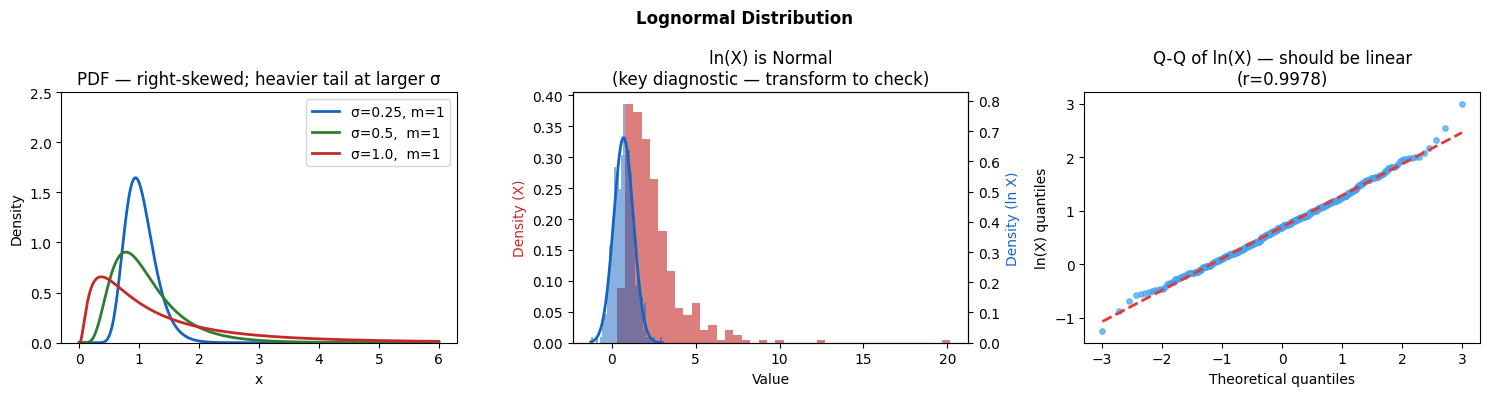

True:  σ=0.6, m=2.0
MLE:   σ̂=0.588, m̂=2.008
Mean of X:   true=2.394, sample=2.406


In [2]:
x = np.linspace(0.001, 6, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Lognormal Distribution', fontsize=12, fontweight='bold')

# PDF — scipy lognorm: s=sigma, scale=m (median)
for sigma, m, color, label in [(0.25, 1, '#1565C0', 'σ=0.25, m=1'),
                                (0.5,  1, '#2E7D32', 'σ=0.5,  m=1'),
                                (1.0,  1, '#C62828', 'σ=1.0,  m=1')]:
    axes[0].plot(x, stats.lognorm(s=sigma, scale=m).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — right-skewed; heavier tail at larger σ')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 2.5)
axes[0].legend()

# Log-transform reveals Normal
np.random.seed(42)
sigma_true, m_true = 0.6, 2.0
sample = stats.lognorm(s=sigma_true, scale=m_true).rvs(500)
log_sample = np.log(sample)

axes[1].hist(sample, bins=40, density=True, color='#C62828', alpha=0.6, label='X (lognormal)')
ax2 = axes[1].twinx()
ax2.hist(log_sample, bins=40, density=True, color='#1565C0', alpha=0.5, label='ln(X) (normal)')
x_norm = np.linspace(log_sample.min(), log_sample.max(), 200)
ax2.plot(x_norm, stats.norm(log_sample.mean(), log_sample.std()).pdf(x_norm),
         color='#1565C0', linewidth=2)
axes[1].set_title('ln(X) is Normal\n(key diagnostic — transform to check)')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('Density (X)', color='#C62828')
ax2.set_ylabel('Density (ln X)', color='#1565C0')

# Q-Q on log scale
(osm, osr), (slope, intercept, r) = stats.probplot(log_sample, dist='norm')
axes[2].scatter(osm, osr, color='#42A5F5', s=15, alpha=0.7)
axes[2].plot([min(osm), max(osm)], [slope*min(osm)+intercept, slope*max(osm)+intercept],
             color='#E53935', linewidth=2, linestyle='--')
axes[2].set_title(f'Q-Q of ln(X) — should be linear\n(r={r:.4f})')
axes[2].set_xlabel('Theoretical quantiles'); axes[2].set_ylabel('ln(X) quantiles')

plt.tight_layout()
plt.show()

# MLE estimation
sigma_hat = log_sample.std()
m_hat = np.exp(log_sample.mean())
print(f"True:  σ={sigma_true}, m={m_true}")
print(f"MLE:   σ̂={sigma_hat:.3f}, m̂={m_hat:.3f}")
print(f"Mean of X:   true={m_true*np.exp(sigma_true**2/2):.3f}, "
      f"sample={sample.mean():.3f}")

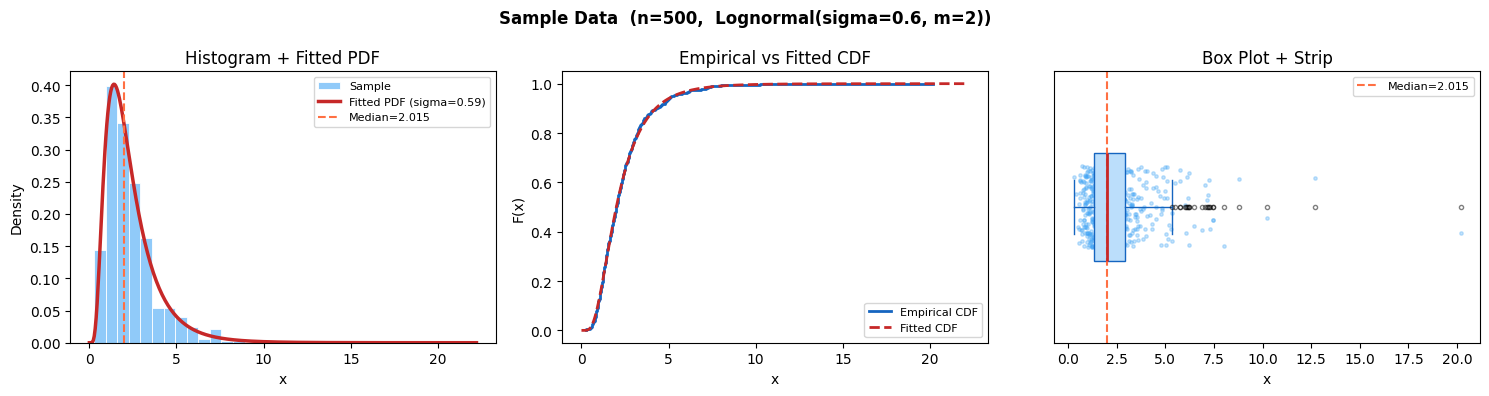

n=500  mean=2.4059  median=2.0154  std=1.7170  skew=3.6028  kurtosis=25.9610


In [3]:
# Sample data plots — Lognormal(sigma=0.6, m=2)
np.random.seed(42)
sample_d = stats.lognorm.rvs(s=0.6, scale=2, size=500)
s_hat, loc_hat, scale_hat = stats.lognorm.fit(sample_d, floc=0)
x_fit = np.linspace(0.01, sample_d.max() * 1.1, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Lognormal(sigma=0.6, m=2))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.lognorm(s_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (sigma={s_hat:.2f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.lognorm(s_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **Defining feature** | $X$ is lognormal $\Leftrightarrow$ $\ln(X)$ is Normal |
| **Shape $\sigma$** | Controls tail heaviness; larger $\sigma$ → more right-skewed |
| **Mean > Median > Mode** | Always true (right-skewed); use median for central tendency |
| **Multiplicative process** | Product of many positive factors → Lognormal (CLT on log scale) |
| **Estimation** | Fit Normal to $\ln(x)$; back-transform: $\hat{m} = e^{\bar{\ln x}}$ |
| **vs Weibull** | Both model failure times; Weibull is more flexible for hazard shapes |
| **Check** | Plot histogram of $\ln(x)$ — should look Normal; Q-Q of $\ln(x)$ should be linear |
